In [6]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

#open file and display first 10 instancec
abt_path = '../data/processed/RecallMe_pp.csv'
df = pd.read_csv(abt_path, sep=',')
df.head(2)

,gender,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,metformin,...,diag_3_Musculoskeletal,diag_3_Neoplasms,diag_3_Other,diag_3_Respiratory,max_glu_serum_0.0,max_glu_serum_1.0,max_glu_serum_2.0,A1Cresult_0.0,A1Cresult_1.0,A1Cresult_2.0
0,0.0,0.181818,0.610526,0.0,0.500000,0.0,0.0,0.0,0.571429,0.0,...,0,0,1,0,1,0,0,1,0,0
1,0.0,0.090909,0.105263,1.0,0.352941,0.0,0.0,0.0,0.285714,0.0,...,0,0,1,0,1,0,0,1,0,0


In [7]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

features = df.columns.tolist()
features.remove("readmitted")

X = df[features]
y = df['readmitted']

# Split the Data into Features and Target
X = df.drop('readmitted', axis=1)  # Features
y = df['readmitted']               # Target

# Split the Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Oversample the Minority Class
#print('Original dataset shape {}'.format(Counter(y_train)))
smote = SMOTE(random_state=20)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
#print('New dataset shape {}'.format(Counter(y_train_resampled)))

train_input_new = pd.DataFrame(X_train_resampled, columns = list(X.columns))
X_train, X_test, y_train, y_test = train_test_split(train_input_new, y_train_resampled, test_size=0.20, random_state=42)



Logistic Regression

Accuracy: 0.9001
Confusion Matrix:
[[10213    68]
 [ 1984  8267]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.99      0.91     10281
         1.0       0.99      0.81      0.89     10251

    accuracy                           0.90     20532
   macro avg       0.91      0.90      0.90     20532
weighted avg       0.91      0.90      0.90     20532


ROC-AUC Score: 0.899921881976285


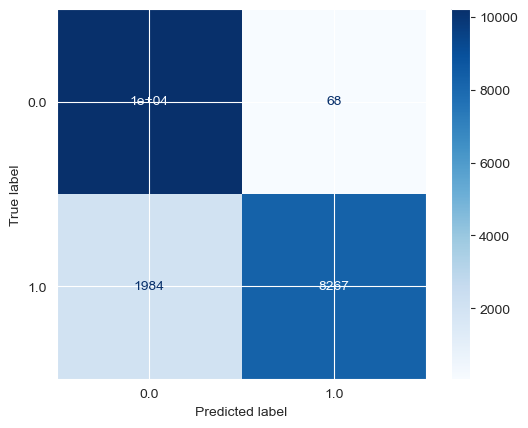

In [8]:
from pyexpat import model
from typing import Counter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, classification_report, recall_score,precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV


# Train the Logistic Regression Model
log_reg = LogisticRegression(max_iter=1000)  # Max iterations if 
log_reg.fit(X_train_resampled, y_train_resampled)

# Evaluate the Model
y_pred = log_reg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)

accuracy_logit = accuracy_score(y_test, y_pred)
precision_logit = precision_score(y_test, y_pred)
recall_logit = recall_score(y_test, y_pred)

f1_logit = f1_score(y_test, y_pred)

conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)


# Print the evaluation results
print()
print("Logistic Regression")
print()
print(f'Accuracy: {accuracy:.4f}')
print('Confusion Matrix:')
print(conf_matrix)
print()
print('Classification Report:')
print(class_report)

print()
roc_auc_logit = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", roc_auc_logit)

cm1 = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=log_reg.classes_)
disp.plot(cmap="Blues")


# Information Based Learning Model

In [9]:
%pip install catboost
%pip install optuna

Note: you may need to restart the kernel to use updated packages.
^C
Note: you may need to restart the kernel to use updated packages.


In [10]:
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
import optuna
from optuna.samplers import TPESampler
import catboost
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import catboost as cb
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTEN
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier



Cat Boost Classifier

Accuracy: 0.9492
Confusion Matrix:
[[10278     3]
 [ 1041  9210]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      1.00      0.95     10281
         1.0       1.00      0.90      0.95     10251

    accuracy                           0.95     20532
   macro avg       0.95      0.95      0.95     20532
weighted avg       0.95      0.95      0.95     20532


ROC-AUC Score: 0.949078565701505


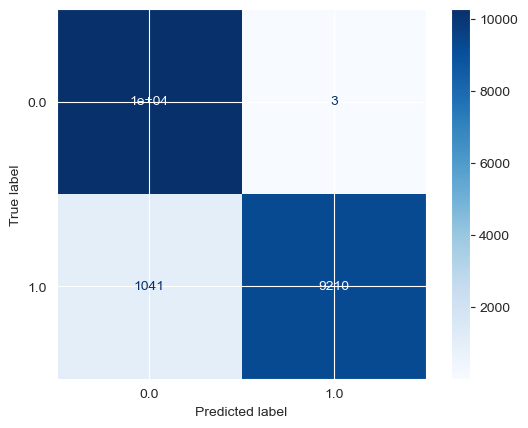

In [11]:
# Initialize the model with default or manually chosen hyperparameters
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    eval_metric='Logloss',
    task_type='CPU',
    verbose=False,
)

# Train the model
model.fit(X_train, y_train)

# Predict
y_pred2 = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred2)
recall = recall_score(y_test,y_pred2)
precision = precision_score(y_test,y_pred2)

accuracy_catBoost = accuracy_score(y_test, y_pred2)
precision_catBoost = precision_score(y_test, y_pred2)
recall_catBoost = recall_score(y_test, y_pred2)

f1_catBoost = f1_score(y_test, y_pred2)

conf_matrix = confusion_matrix(y_test, y_pred2)
class_report = classification_report(y_test, y_pred2)

# Print the evaluation results
print()
print("Cat Boost Classifier")
print()
print(f'Accuracy: {accuracy:.4f}')
print('Confusion Matrix:')
print(conf_matrix)
print()
print('Classification Report:')
print(class_report)

print()
roc_auc_catBoost = roc_auc_score(y_test, y_pred2)
print("ROC-AUC Score:", roc_auc_catBoost)

# # Evaluate
# f1 = f1_score(y_test, y_pred, average='micro')
# print(f"F1 Score: {f1}")
# print(classification_report(y_test, y_pred))

cm2 = confusion_matrix(y_test, y_pred2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=model.classes_)
disp.plot(cmap="Blues")

In [13]:
def objective(trial):
    model = catboost.CatBoostClassifier(
        iterations=trial.suggest_int("iterations", 100, 1000),
        learning_rate=trial.suggest_float("learning_rate", 1e-3, 1e-1, log=True),
        depth=trial.suggest_int("depth", 4, 10),
        boosting_type= trial.suggest_categorical("boosting_type", ["Ordered", "Plain"]),
        bootstrap_type=trial.suggest_categorical(
            "bootstrap_type", ["Bayesian", "MVS"]
        ),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1e-8, 100.0, log=True),
        #bootstrap_type=trial.suggest_categorical("bootstrap_type", ["Bayesian"]),
        random_strength=trial.suggest_float("random_strength", 1e-8, 10.0, log=True),
        bagging_temperature=trial.suggest_float("bagging_temperature", 0.0, 10.0),
        od_type=trial.suggest_categorical("od_type", ["IncToDec", "Iter"]),
        od_wait=trial.suggest_int("od_wait", 10, 50),
        #max_leaves=trial.suggest_int("max_leaves",15,40),
        min_data_in_leaf=trial.suggest_int("min_data_in_leaf",51,120),
        loss_function='Logloss',
        eval_metric='Logloss',
        task_type='CPU',
        verbose=False,
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return f1_score(y_test, y_pred,average='micro')

In [14]:
## we ran this with 20 trials originally but it is set to two right now to decrease the wait time from 2hrs 12s

##%%time

optuna.logging.set_verbosity(optuna.logging.INFO)

sampler = TPESampler(seed=1)
study = optuna.create_study(study_name="catboost", direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=2)


[I 2025-01-19 19:30:35,204] A new study created in memory with name: catboost
[I 2025-01-19 19:31:36,282] Trial 0 finished with value: 0.9465712059224625 and parameters: {'iterations': 475, 'learning_rate': 0.027583475549166746, 'depth': 4, 'boosting_type': 'Ordered', 'bootstrap_type': 'MVS', 'l2_leaf_reg': 2.855007611568483e-05, 'random_strength': 3.72312200494449e-05, 'bagging_temperature': 5.3881673400335695, 'od_type': 'Iter', 'od_wait': 18, 'min_data_in_leaf': 112}. Best is trial 0 with value: 0.9465712059224625.
[I 2025-01-19 19:32:04,413] Trial 1 finished with value: 0.9331287745957529 and parameters: {'iterations': 124, 'learning_rate': 0.021924768698806385, 'depth': 6, 'boosting_type': 'Ordered', 'bootstrap_type': 'MVS', 'l2_leaf_reg': 48.15215820395775, 'random_strength': 6.6193844201488494e-06, 'bagging_temperature': 6.923226156693141, 'od_type': 'Iter', 'od_wait': 13, 'min_data_in_leaf': 53}. Best is trial 0 with value: 0.9465712059224625.


Choose best parameters based on study

In [15]:
#params={'iterations': 992, 'learning_rate': 0.0972624545345653, 'depth': 8, 'boosting_type': 'Plain', 'bootstrap_type': 'Bayesian', 'l2_leaf_reg': 1.612019991200224, 'random_strength': 0.0015362215536542452, 'bagging_temperature': 0.07118980713182665, 'od_type': 'IncToDec', 'od_wait': 22, 'min_data_in_leaf': 75}
#params={'iterations': 994, 'learning_rate': 0.006659183787398087, 'depth': 10, 'boosting_type': 'Ordered', 'bootstrap_type': 'Bayesian', 'l2_leaf_reg': 0.04433321436253833, 'random_strength': 1.1739840076657603e-06, 'bagging_temperature': 0.2831908721116907, 'od_type': 'Iter', 'od_wait': 33, 'min_data_in_leaf': 72}
params = {'iterations': 774, 'learning_rate': 0.03968958254108786, 'depth': 8, 'boosting_type': 'Plain', 'bootstrap_type': 'MVS', 'l2_leaf_reg': 1.1899108535629813e-08, 'random_strength': 7.611506818263252e-07, 'bagging_temperature': 3.2722259417874335, 'od_type': 'Iter', 'od_wait': 16, 'min_data_in_leaf': 60}

In [16]:
# Takes about 2  Minutes to run

newmodel = catboost.CatBoostClassifier(**params,verbose=False)
newmodel.fit(X_train,y_train)
probs = newmodel.predict_proba(X_test)

y_pred3 = newmodel.predict(X_test)


accuracy = accuracy_score(y_test, y_pred3)
recall = recall_score(y_test,y_pred3)
precision = precision_score(y_test,y_pred3)

accuracy_catBoostParams = accuracy_score(y_test, y_pred3)
precision_catBoostParams = precision_score(y_test, y_pred3)
recall_catBoostParams = recall_score(y_test, y_pred3)

f1_catBoostParams = f1_score(y_test, y_pred3)

conf_matrix = confusion_matrix(y_test, y_pred3)
class_report = classification_report(y_test, y_pred3)

# Print the evaluation results
print()
print("Cat Boost Classifier with params")
print()
print(f'Accuracy: {accuracy:.4f}')
print('Confusion Matrix:')
print(conf_matrix)
print()
print('Classification Report:')
print(class_report)

print()
roc_auc_catBoostParams = roc_auc_score(y_test, y_pred3)
print("ROC-AUC Score:", roc_auc_catBoostParams)



Cat Boost Classifier with params

Accuracy: 0.9495
Confusion Matrix:
[[10272     9]
 [ 1027  9224]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      1.00      0.95     10281
         1.0       1.00      0.90      0.95     10251

    accuracy                           0.95     20532
   macro avg       0.95      0.95      0.95     20532
weighted avg       0.95      0.95      0.95     20532


ROC-AUC Score: 0.9494696255017445


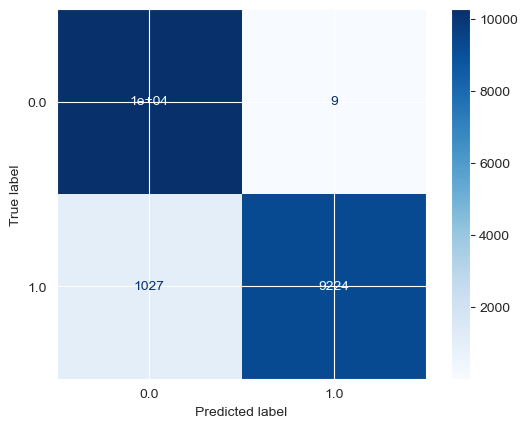

In [17]:
# Generate and display confusion matrix
cm = confusion_matrix(y_test, y_pred3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues")


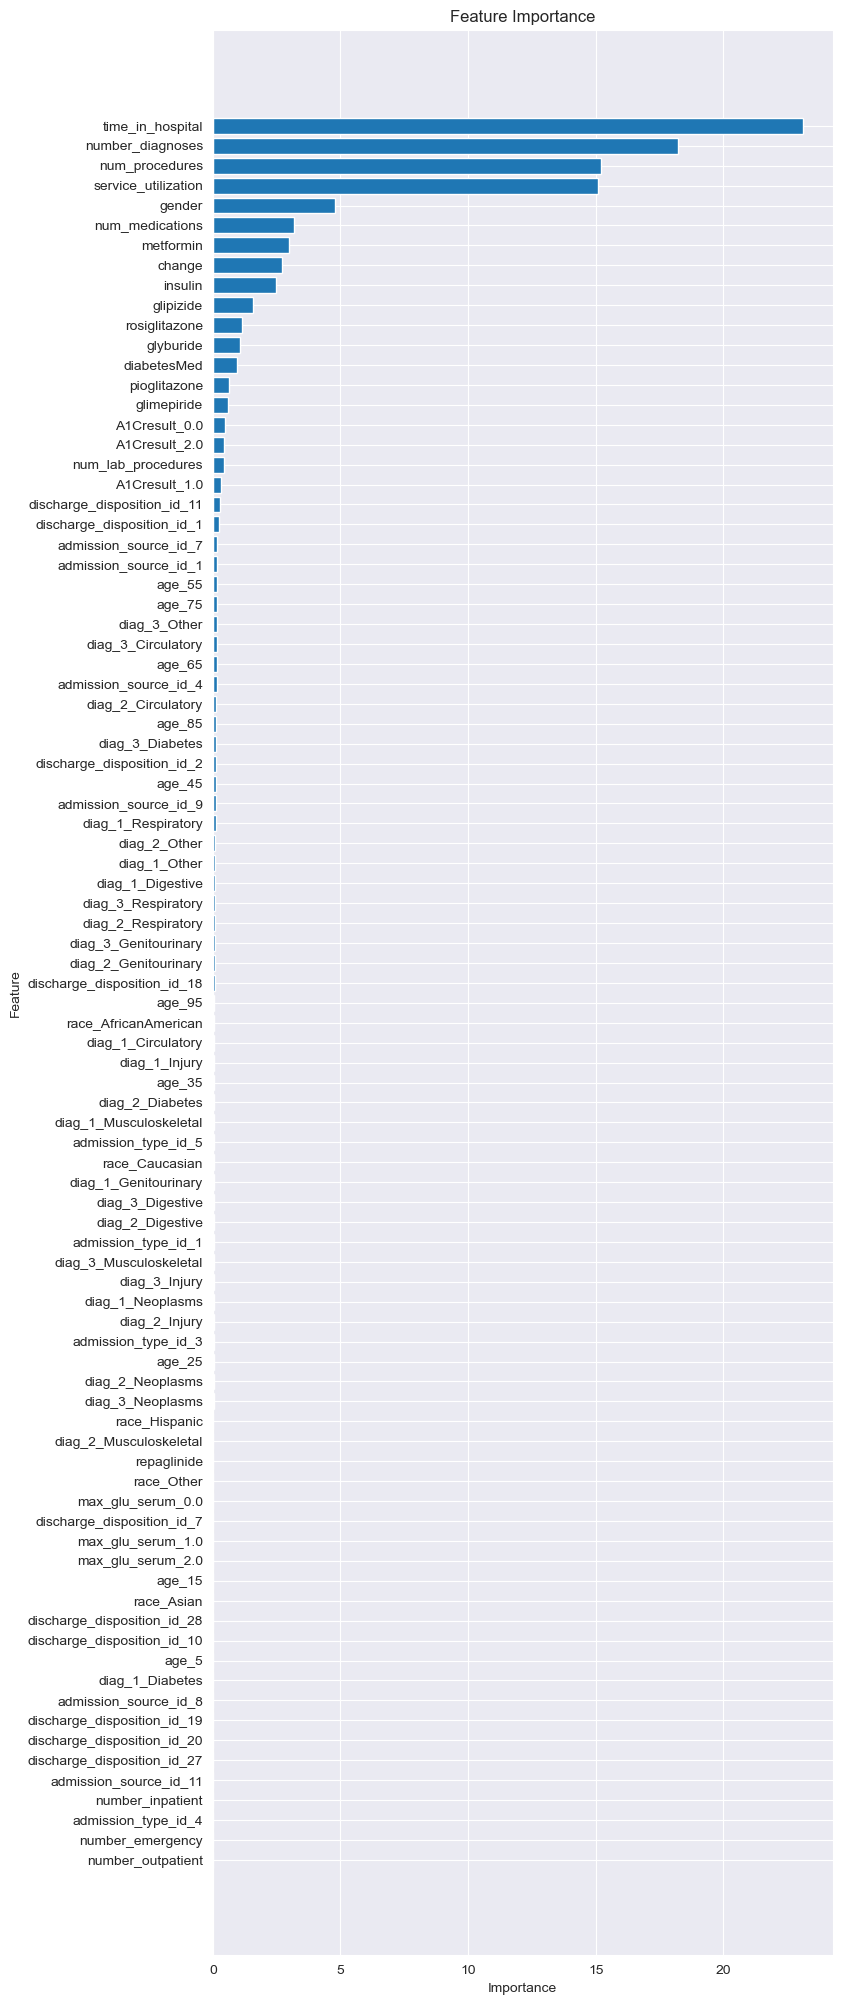

In [18]:

# Get feature importance
feature_importance = model.get_feature_importance()
features = X_train.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(8, 25))
plt.barh(importance_df['Feature'], importance_df['Importance'], align='center')
plt.gca().invert_yaxis()  # Most important features on top
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()


### Probability Based Learning

In [19]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTEN
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier

pd.set_option('display.max_columns', None)

df.head(2)

,gender,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,metformin,repaglinide,glimepiride,glipizide,glyburide,pioglitazone,rosiglitazone,insulin,change,diabetesMed,readmitted,service_utilization,race_AfricanAmerican,race_Asian,race_Caucasian,race_Hispanic,race_Other,age_15,age_25,age_35,age_45,age_5,age_55,age_65,age_75,age_85,age_95,admission_type_id_1,admission_type_id_3,admission_type_id_4,admission_type_id_5,discharge_disposition_id_1,discharge_disposition_id_10,discharge_disposition_id_11,discharge_disposition_id_18,discharge_disposition_id_19,discharge_disposition_id_2,discharge_disposition_id_20,discharge_disposition_id_27,discharge_disposition_id_28,discharge_disposition_id_7,admission_source_id_1,admission_source_id_11,admission_source_id_4,admission_source_id_7,admission_source_id_8,admission_source_id_9,diag_1_Circulatory,diag_1_Diabetes,diag_1_Digestive,diag_1_Genitourinary,diag_1_Injury,diag_1_Musculoskeletal,diag_1_Neoplasms,diag_1_Other,diag_1_Respiratory,diag_2_Circulatory,diag_2_Diabetes,diag_2_Digestive,diag_2_Genitourinary,diag_2_Injury,diag_2_Musculoskeletal,diag_2_Neoplasms,diag_2_Other,diag_2_Respiratory,diag_3_Circulatory,diag_3_Diabetes,diag_3_Digestive,diag_3_Genitourinary,diag_3_Injury,diag_3_Musculoskeletal,diag_3_Neoplasms,diag_3_Other,diag_3_Respiratory,max_glu_serum_0.0,max_glu_serum_1.0,max_glu_serum_2.0,A1Cresult_0.0,A1Cresult_1.0,A1Cresult_2.0
0,0.0,0.181818,0.610526,0.0,0.500000,0.0,0.0,0.0,0.571429,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0
1,0.0,0.090909,0.105263,1.0,0.352941,0.0,0.0,0.0,0.285714,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0


<Axes: >

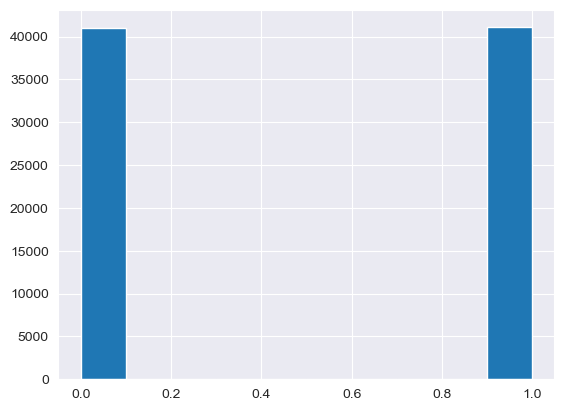

In [20]:
 #Has been applied already SMOTE (Synthetic Minority Over-sampling Technique) for handling class imbalance
y_train.hist()


Prob Classifier

Accuracy: 0.5441
Confusion Matrix:
[[ 1122  9159]
 [  202 10049]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.11      0.19     10281
         1.0       0.52      0.98      0.68     10251

    accuracy                           0.54     20532
   macro avg       0.69      0.54      0.44     20532
weighted avg       0.69      0.54      0.44     20532


ROC-AUC Score: 0.5447139790955223


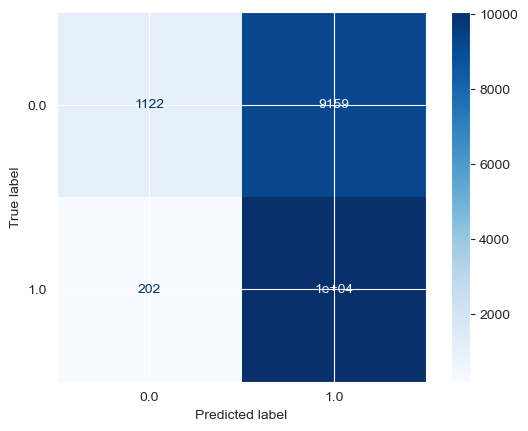

In [21]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

# Build a Gaussian Classifier
model = GaussianNB()

# Model training
model.fit(X_train, y_train)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

y_pred4 = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred4)
recall = recall_score(y_test,y_pred4)
precision = precision_score(y_test,y_pred4)

accuracy_prob = accuracy_score(y_test, y_pred4)
precision_prob = precision_score(y_test, y_pred4)
recall_prob = recall_score(y_test, y_pred4)

f1_prob = f1_score(y_test, y_pred4)

conf_matrix = confusion_matrix(y_test, y_pred4)
class_report = classification_report(y_test, y_pred4)

# Print the evaluation results
print()
print("Prob Classifier")
print()
print(f'Accuracy: {accuracy:.4f}')
print('Confusion Matrix:')
print(conf_matrix)
print()
print('Classification Report:')
print(class_report)

print()
roc_auc_prob = roc_auc_score(y_test, y_pred4)
print("ROC-AUC Score:", roc_auc_prob)

cm3 = confusion_matrix(y_test, y_pred4)
disp = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=model.classes_)
disp.plot(cmap="Blues")

# **SIMILARITY-BASED LEARNING**

In [22]:
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier


In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

params = {
    'n_neighbors': [7],
    'metric': ['euclidean'],  # Reduced to just one metric
    'weights': ['distance']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid=params, scoring='roc_auc', cv=5)

grid.fit(X_train, y_train)  # Use X_train and y_train, not X_train_smote and y_train_smote

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean'], 'n_neighbors': [7],
                         'weights': ['distance']},
             scoring='roc_auc')


Similarity Classifier

Accuracy: 0.7993
Confusion Matrix:
[[ 6228  4053]
 [   67 10184]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.61      0.75     10281
         1.0       0.72      0.99      0.83     10251

    accuracy                           0.80     20532
   macro avg       0.85      0.80      0.79     20532
weighted avg       0.85      0.80      0.79     20532

ROC-AUC Score: 0.9586682317788113


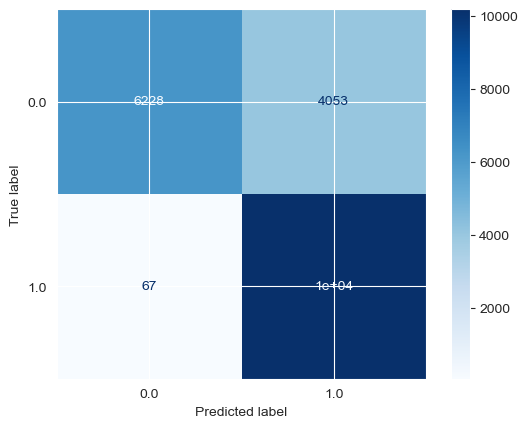

In [24]:
best_knn = grid.best_estimator_  # Get the best model from GridSearchCV
best_knn.fit(X_train, y_train)
y_pred5 = best_knn.predict(X_test)
y_pred_proba = best_knn.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred5)
recall = recall_score(y_test,y_pred5)
precision = precision_score(y_test,y_pred5)

accuracy_knn = accuracy_score(y_test, y_pred5)
precision_knn = precision_score(y_test, y_pred5)
recall_knn = recall_score(y_test, y_pred5)

f1_knn = f1_score(y_test, y_pred5)

conf_matrix = confusion_matrix(y_test, y_pred5)
class_report = classification_report(y_test, y_pred5)

# Print the evaluation results
print()
print("Similarity Classifier")
print()
print(f'Accuracy: {accuracy:.4f}')
print('Confusion Matrix:')
print(conf_matrix)
print()
print('Classification Report:')
print(class_report)

roc_auc_KNN = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC Score:", roc_auc_KNN)

cm4 = confusion_matrix(y_test, y_pred5)
disp = ConfusionMatrixDisplay(confusion_matrix=cm4, display_labels=model.classes_)
disp.plot(cmap="Blues")

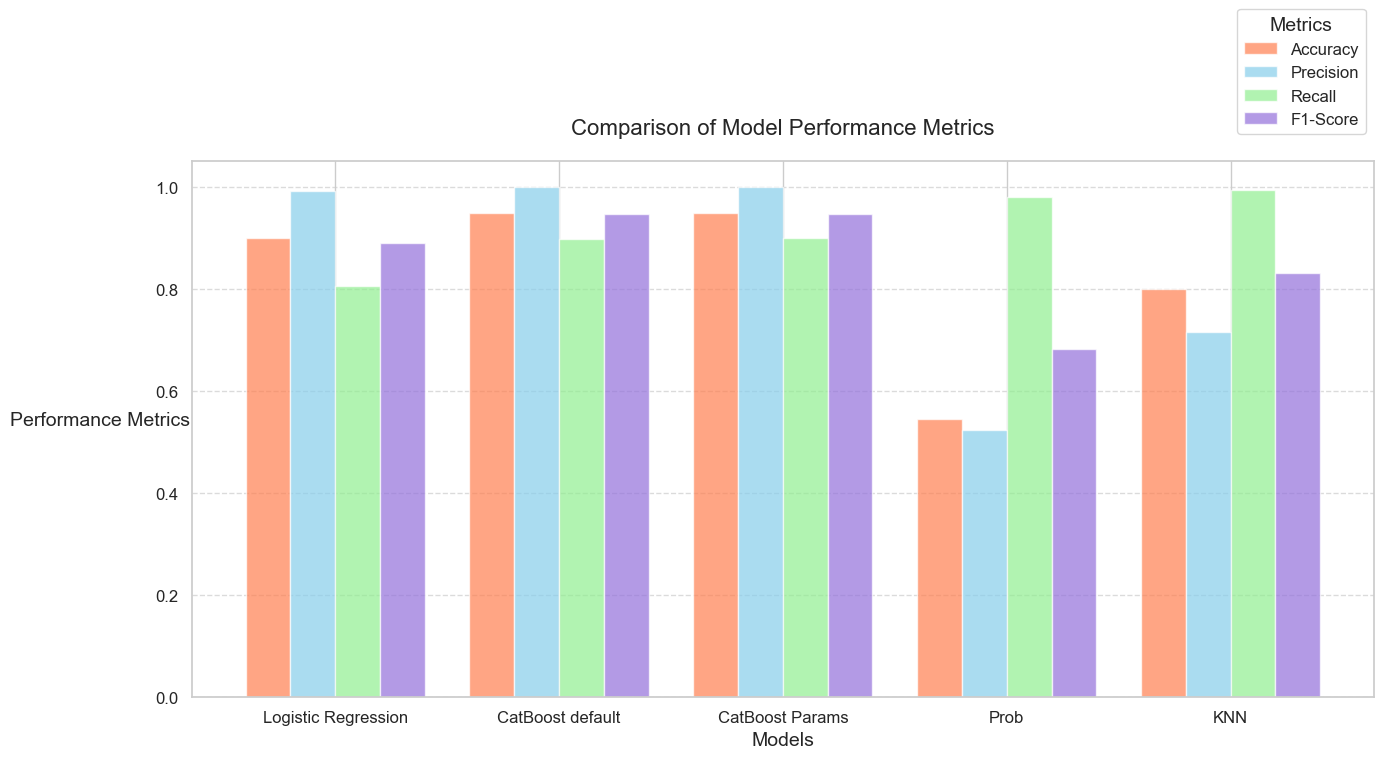

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import f1_score

# Set the aesthetics for seaborn
sns.set(style="whitegrid")

# Model names and metrics
models = ['Logistic Regression', 'CatBoost default', 'CatBoost Params', 'Prob', 'KNN']
accuracy_values = [accuracy_logit, accuracy_catBoost, accuracy_catBoostParams, accuracy_prob, accuracy_knn]
precision_values = [precision_logit, precision_catBoost, precision_catBoostParams, precision_prob, precision_knn]
recall_values = [recall_logit, recall_catBoost, recall_catBoostParams, recall_prob, recall_knn]
f1_values = [f1_logit, f1_catBoost, f1_catBoostParams, f1_prob, f1_knn]

# Position for the bars
bar_width = 0.2
indices = np.arange(len(models))

# Create a figure
plt.figure(figsize=(14, 8))

# Plot accuracy bars
plt.bar(indices, accuracy_values, bar_width, alpha=0.7, label='Accuracy', color='coral')

# Plot precision bars
plt.bar(indices + bar_width, precision_values, bar_width, alpha=0.7, label='Precision', color='skyblue')

# Plot recall bars
plt.bar(indices + 2 * bar_width, recall_values, bar_width, alpha=0.7, label='Recall', color='lightgreen')

# Plot F1-score bars
plt.bar(indices + 3 * bar_width, f1_values, bar_width, alpha=0.7, label='F1-Score', color='mediumpurple')

# Add titles and labels
plt.xlabel('Models', fontsize=14)
plt.ylabel('Performance Metrics', fontsize=14, rotation=0, labelpad=40)
plt.title('Comparison of Model Performance Metrics', fontsize=16, pad=20)
plt.xticks(indices + 1.5 * bar_width, models, fontsize=12, rotation=0)
plt.yticks(fontsize=12)

# Add grid lines for better readability
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Add legend with adjusted position
plt.legend(title='Metrics', fontsize=12, title_fontsize=14, loc='upper right', bbox_to_anchor=(1.0, 1.3))

# Tight layout to adjust spacing
plt.tight_layout()

# Show the plot
plt.show()


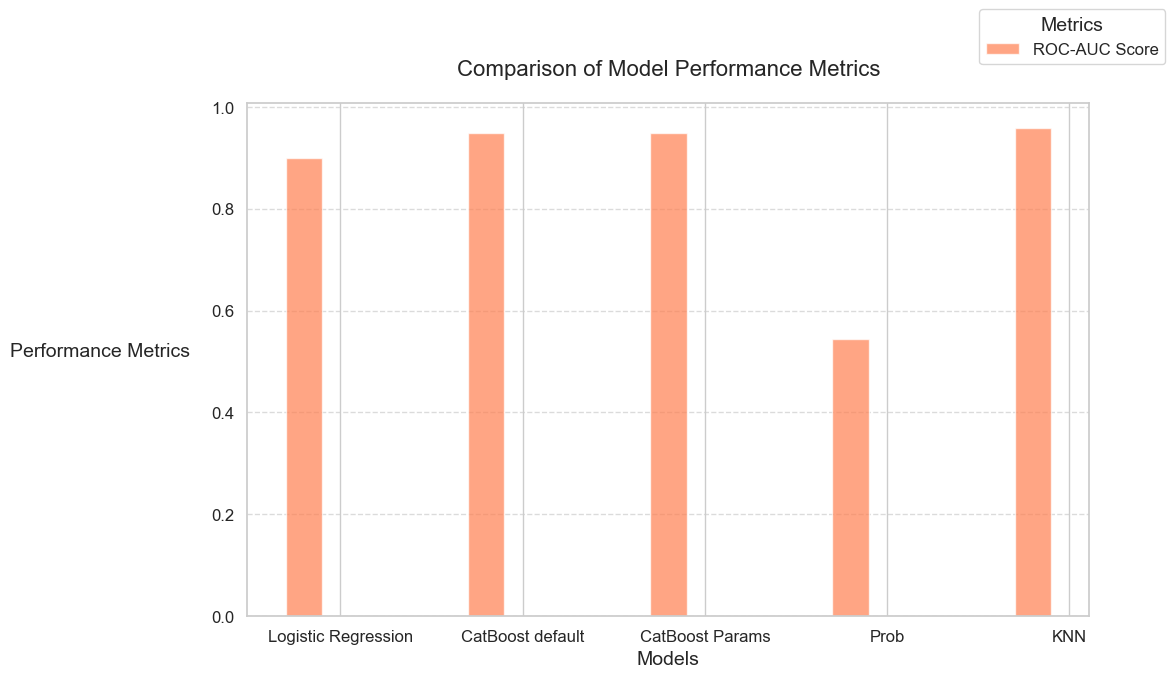

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the aesthetics for seaborn
sns.set(style="whitegrid")

# Model names and metrics
models = ['Logistic Regression', 'CatBoost default', 'CatBoost Params', 'Prob', 'KNN']

ROC_AUC = [roc_auc_logit, roc_auc_catBoost, roc_auc_catBoostParams, roc_auc_prob, roc_auc_KNN]

# Position for the bars
bar_width = 0.2
indices = np.arange(len(models))

# Create a figure
plt.figure(figsize=(12, 7))

# Plot accuracy bars
plt.bar(indices, ROC_AUC, bar_width, alpha=0.7, label='ROC-AUC Score', color='coral')

# Add titles and labels
plt.xlabel('Models', fontsize=14)
plt.ylabel('Performance Metrics', fontsize=14,rotation=0, labelpad=80)
plt.title('Comparison of Model Performance Metrics', fontsize=16, pad=20)
plt.xticks(indices + bar_width, models, fontsize=12, rotation=0)
plt.yticks(fontsize=12)

# Add grid lines for better readability
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Add legend
plt.legend(title='Metrics', fontsize=12, title_fontsize=14 , loc='upper right', bbox_to_anchor=(1.1, 1.2))

# Tight layout to adjust spacing
plt.tight_layout()

# Show the plot
plt.show()


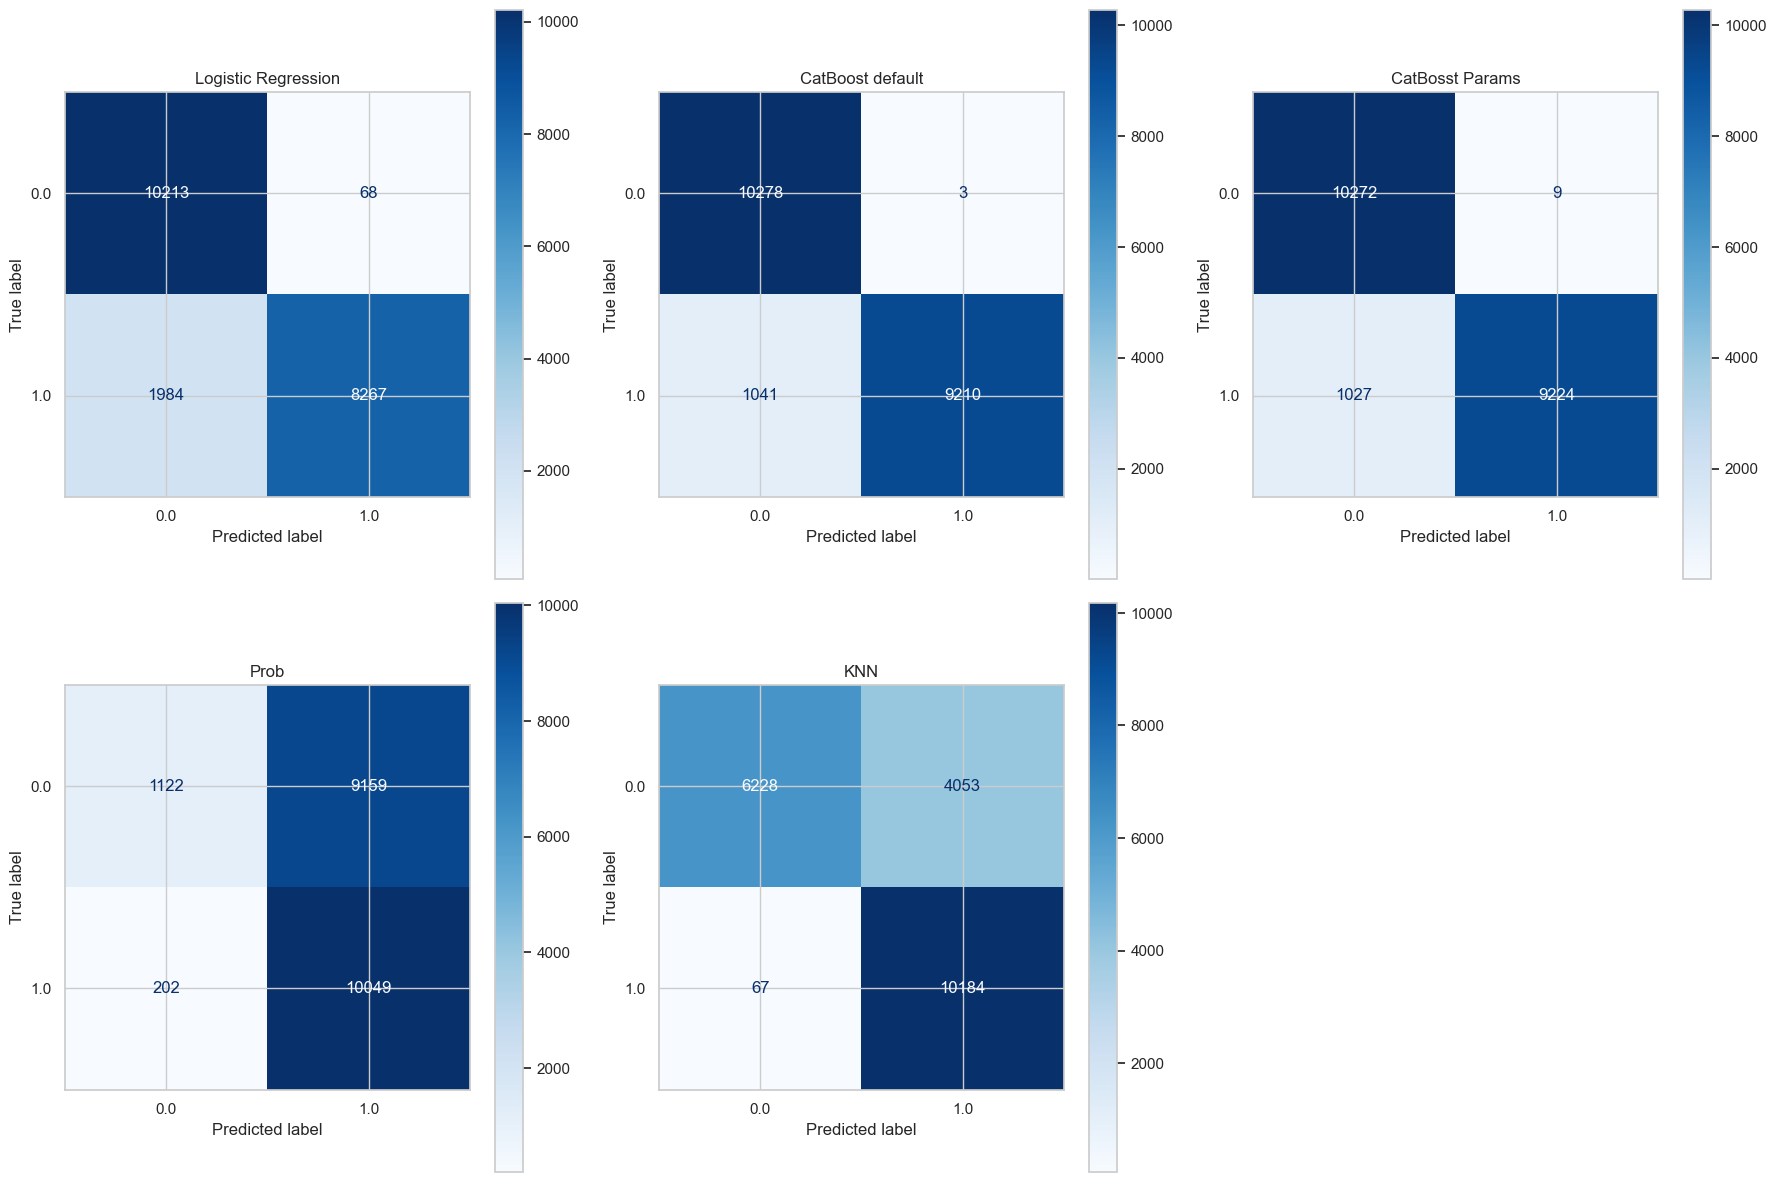

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate confusion matrices
cm = confusion_matrix(y_test, y_pred)
cm1 = confusion_matrix(y_test, y_pred2)
cm2 = confusion_matrix(y_test, y_pred3)
cm3 = confusion_matrix(y_test, y_pred4)
cm4 = confusion_matrix(y_test, y_pred5)

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues", ax=axes[0, 0], values_format="d")
axes[0, 0].set_title('Logistic Regression')

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=model.classes_)
disp.plot(cmap="Blues", ax=axes[0, 1], values_format="d")
axes[0, 1].set_title('CatBoost default')

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=model.classes_)
disp.plot(cmap="Blues", ax=axes[0, 2], values_format="d")
axes[0, 2].set_title('CatBosst Params')

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=model.classes_)
disp.plot(cmap="Blues", ax=axes[1, 0], values_format="d")
axes[1, 0].set_title('Prob')

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm4, display_labels=model.classes_)
disp.plot(cmap="Blues", ax=axes[1, 1], values_format="d")
axes[1, 1].set_title('KNN')

# Hide the empty subplot (axes[1, 2])
axes[1, 2].axis('off')

# Adjust layout
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300)
plt.show()
